# Notebook to demo weighted statistics.

```terminal
uv pip install -U statsmodels
```

- https://www.statsmodels.org/dev/generated/statsmodels.stats.weightstats.DescrStatsW.html
- https://spark.apache.org/docs/3.2.0/api/python/reference/api/pyspark.sql.GroupedData.applyInPandas.html

In [1]:
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from statsmodels.stats.weightstats import DescrStatsW

### Create blobs of weighted data.

In [2]:
n_samples = 500
centers = [[1, 1], [-1, -1], [1, -1]]
x, cluster = make_blobs(n_samples=n_samples, centers=centers, cluster_std=0.3)
x *= 10_000.0
w = 100.0 * np.random.random(n_samples)

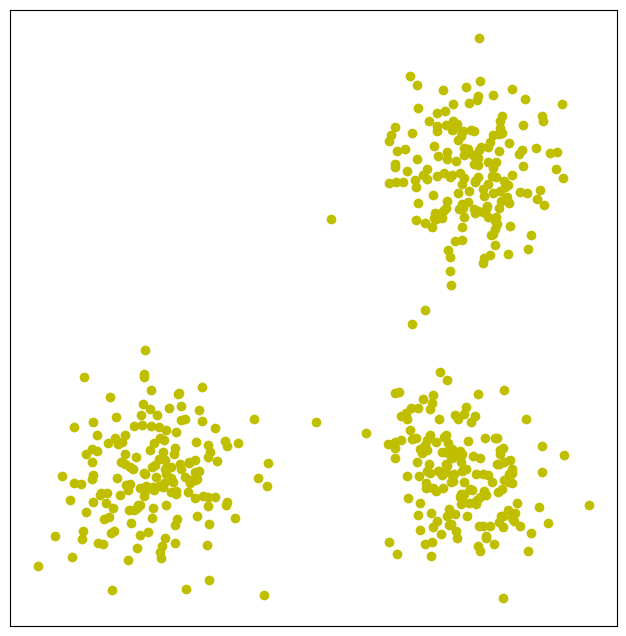

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_aspect(1)
plt.plot(
    x[:, 0],
    x[:, 1],
    "yo",
)
plt.xticks([])
plt.yticks([])
plt.show()

### Create a pandas dataframe.

In [4]:
pdf = pd.DataFrame({"x": x[:, 0], "y": x[:, 1], "w": w, "c": cluster})

In [5]:
# pdf.to_csv("xyw.csv", header=True, index=False)

### Create a spark dataframe from pandas dataframe.

In [6]:
sdf = spark.createDataFrame(pdf)

### Create stats function to be called on a group.

In [7]:
def stats(df):
    w = df["w"]
    x = DescrStatsW(df["x"], w)
    y = DescrStatsW(df["y"], w)
    cx = [x.mean]
    cy = [y.mean]
    sd = [np.sqrt(x.var + y.var)]
    return pd.DataFrame(OrderedDict([("cx", cx), ("cy", cy), ("sd", sd)]))

### Calculate the standard distances.

In [8]:
xyr = (
    sdf.groupBy("c")
    .applyInPandas(stats, schema="cx double, cy double, sd double")
    .collect()
)

### Let's plot them.

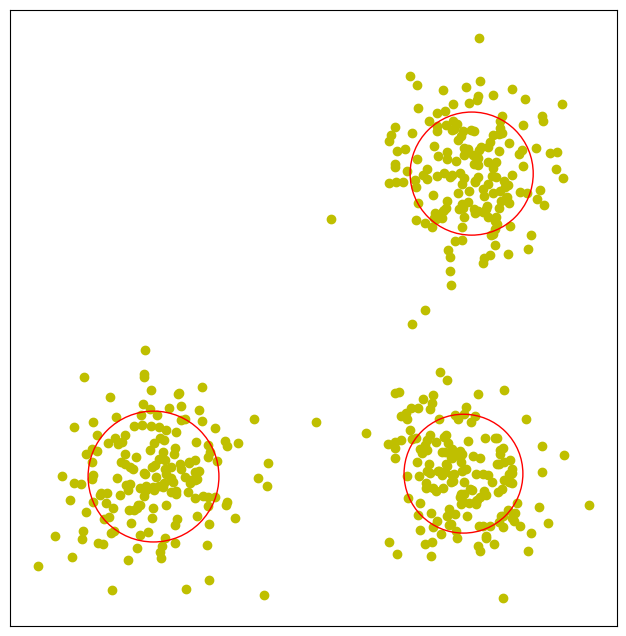

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_aspect(1)
plt.plot(
    x[:, 0],
    x[:, 1],
    "yo",
)

for x_, y_, r_ in xyr:
    ax.add_artist(plt.Circle((x_, y_), r_, ec="red", fill=False, zorder=99))

plt.xticks([])
plt.yticks([])
plt.show()